# Aufgabe 3 – Katz-und-Maus-Verfolgungskurve

## Problemstellung

Eine Katze jagt in der $(x,y)$-Ebene einer Maus hinterher:

| | Startpunkt | Geschwindigkeit | Ziel |
|---|---|---|---|
| Maus | $(0, 0)$ | $v_M = 1$ | $(0, 1)$ |
| Katze | $(1, 0)$ | $v_K = 2$ | — (verfolgt Maus) |

Die Maus läuft **geradlinig** entlang der $y$-Achse in Richtung ihres Lochs bei $(0,1)$.  
Die Katze läuft stets **direkt auf die aktuelle Position der Maus zu**.

---

## Mausposition

Da die Maus mit $v_M = 1$ geradlinig auf der $y$-Achse läuft, gilt:
$$\vec{r}_M(t) = (0,\; t)$$
(bis sie bei $(0,1)$ ankommt, also für $t \le 1$).

---

## Differentialgleichung der Katzenbahn

Sei $\vec{r}_K(t) = (x(t),\, y(t))$ die Position der Katze.  
Der Einheitsvektor von der Katze zur Maus ist:
$$\hat{e}(t) = \frac{\vec{r}_M(t) - \vec{r}_K(t)}{\|\vec{r}_M(t) - \vec{r}_K(t)\|}$$

Damit lautet das **Anfangswertproblem**:

$$\dot{x} = v_K \cdot \frac{0 - x}{\sqrt{x^2 + (t - y)^2}}, \qquad x(0) = 1$$

$$\dot{y} = v_K \cdot \frac{t - y}{\sqrt{x^2 + (t - y)^2}}, \qquad y(0) = 0$$

---

## Fragen

1. Löse das AWP numerisch mit dem **expliziten Euler-Verfahren**.
2. Schafft es die Maus ins Loch? Falls nein: **wann** und **wo** wird sie gefangen?
3. Plotte die Bahnkurven beider Tiere.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [ ]:
vK = 2.0          
vM = 1.0          
maus_ziel = (0.0, 1.0)

x0, y0 = 1.0, 0.0   # Katze


tau = 0.001    # Schrittweite
t = 0.0

u = np.array([1.0, 0.0])   
trajektorie = [u.copy()]

while True:
    maus = np.array([0.0, vM * t])

    if np.linalg.norm(maus - np.array([0.0, 1.0])) < tau:
        print(f"Maus entkommen bei t={t:.4f}")
        break
    
    diff = maus - u
    dist = np.linalg.norm(diff)

    if dist < tau:
        print(f"Katze fängt Maus bei t={t:.4f}, Ort=({u[0]:.4f}, {u[1]:.4f})")
        break
    
    u = u + tau * vK * diff / dist
    t = t + tau
    trajektorie.append(u.copy())

Katze fängt Maus bei t=0.6670, Ort=(-0.0000, 0.6670)


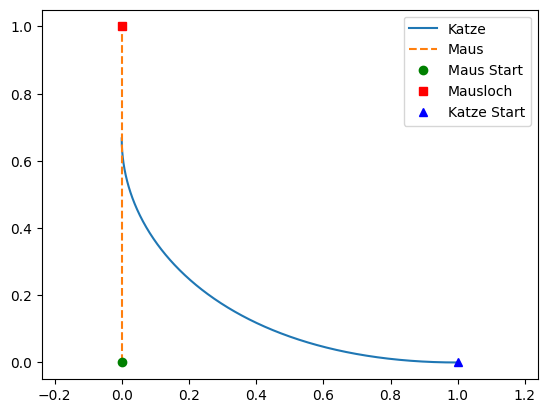

In [6]:
trajektorie = np.array(trajektorie)
t_werte = np.linspace(0, t, len(trajektorie))

plt.plot(trajektorie[:, 0], trajektorie[:, 1], label="Katze")
plt.plot([0, 0], [0, 1], '--', label="Maus")
plt.plot(0, 0, 'go', label="Maus Start")
plt.plot(0, 1, 'rs', label="Mausloch")
plt.plot(1, 0, 'b^', label="Katze Start")
plt.axis('equal')
plt.legend()
plt.show()